Import delle librerie   

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & Embedding
import gensim
import gensim.downloader as api
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

# Machine Learning & Metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, confusion_matrix)

print("Librerie importate con successo!")

Librerie importate con successo!


Caricamento Dati e Label Encoding

In [2]:
# Caricamento dei dataset
train_df = pd.read_csv('../data/train_set.csv')
test_df = pd.read_csv('../data/test_set.csv')

# Conversione della variabile target in numerica
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])

# Mapping classi per riferimento futuro
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(f"Classi mappate: {class_mapping}")
print(f"Dimensioni Train: {train_df.shape} | Dimensioni Test: {test_df.shape}")

Classi mappate: {'bug': np.int64(0), 'feature': np.int64(1)}
Dimensioni Train: (32650, 2) | Dimensioni Test: (13994, 2)


Preprocessing e Tokenizzazione

In [3]:
def tokenize_and_filter(text):
    """Tokenizzazione leggera e rimozione delle stopwords."""
    tokens = simple_preprocess(str(text))
    return [token for token in tokens if token not in STOPWORDS]

print("Tokenizzazione in corso...")
train_df['tokens'] = train_df['text'].apply(tokenize_and_filter)
test_df['tokens'] = test_df['text'].apply(tokenize_and_filter)
print("Tokenizzazione completata!")

Tokenizzazione in corso...
Tokenizzazione completata!


Addestramento Word2Vec Custom

In [4]:
print("Addestramento di Word2Vec Custom sui dati di Train...")

w2v_model = Word2Vec(
    sentences=train_df['tokens'],
    vector_size=100,
    window=5,
    sg=1,          # Skip-gram
    min_count=2,   # Filtro parole rare
    workers=4
)

print(f"Addestramento completato! Vocabolario: {len(w2v_model.wv)} parole.")

Addestramento di Word2Vec Custom sui dati di Train...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Addestramento completato! Vocabolario: 77441 parole.


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Funzione di Vettorizzazione Media

In [5]:
def get_mean_vector(tokens, model, vector_size=100):
    """
    Calcola la media dei vettori dei token presenti nel vocabolario.
    Funziona sia con Word2Vec (model.wv) che con GloVe (model).
    """
    # Gestione differenza tra Word2Vec (KeyedVectors in .wv) e GloVe (già KeyedVectors)
    vectors = model.wv if hasattr(model, 'wv') else model
    
    valid_vectors = [vectors[word] for word in tokens if word in vectors]
    
    if not valid_vectors:
        return np.zeros(vector_size)
    
    return np.mean(valid_vectors, axis=0)

# Generazione matrici feature Word2Vec
X_train_w2v = np.vstack(train_df['tokens'].apply(lambda x: get_mean_vector(x, w2v_model)))
X_test_w2v = np.vstack(test_df['tokens'].apply(lambda x: get_mean_vector(x, w2v_model)))

print(f"Feature Word2Vec pronte. Shape: {X_train_w2v.shape}")

Feature Word2Vec pronte. Shape: (32650, 100)


Caricamento GloVe e Vettorizzazione

In [6]:
print("Caricamento di GloVe (glove-wiki-gigaword-100)...")
glove_model = api.load("glove-wiki-gigaword-100")

# Generazione matrici feature GloVe
X_train_glove = np.vstack(train_df['tokens'].apply(lambda x: get_mean_vector(x, glove_model)))
X_test_glove = np.vstack(test_df['tokens'].apply(lambda x: get_mean_vector(x, glove_model)))

print(f"Feature GloVe pronte. Shape: {X_train_glove.shape}")

Caricamento di GloVe (glove-wiki-gigaword-100)...
Feature GloVe pronte. Shape: (32650, 100)


Definizione Helper per Machine Learning

In [7]:
def train_tuned_model(clf, params, X_train, y_train):
    grid = GridSearchCV(clf, params, cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid

def calculate_metrics(y_true, y_pred, grid_obj):
    return {
        "best_params": grid_obj.best_params_,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average='macro')),
        "recall": float(recall_score(y_true, y_pred, average='macro')),
        "f1_score": float(f1_score(y_true, y_pred, average='macro')),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }

Pipeline di Esecuzione Esperimento

In [8]:
def run_classification_pipeline(exp_name, X_train, y_train, X_test, y_test):
    """Fattorizzazione dei 3 modelli per ogni tipo di embedding."""
    print(f"\n>>> Avvio Esperimento: {exp_name}")
    results = {}

    # 1. Logistic Regression
    grid_lr = train_tuned_model(
        LogisticRegression(max_iter=500, random_state=42),
        {'C': [0.1, 1, 10]}, X_train, y_train
    )
    results["logistic_regression"] = calculate_metrics(y_test, grid_lr.best_estimator_.predict(X_test), grid_lr)

    # 2. Decision Tree
    grid_dt = train_tuned_model(
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [5, 10]}, X_train, y_train
    )
    results["decision_tree"] = calculate_metrics(y_test, grid_dt.best_estimator_.predict(X_test), grid_dt)

    # 3. SVM
    grid_svm = train_tuned_model(
        SVC(random_state=42),
        {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}, X_train, y_train
    )
    results["svm"] = calculate_metrics(y_test, grid_svm.best_estimator_.predict(X_test), grid_svm)

    return results

Funzione di Visualizzazione

In [9]:
def plot_confusion_matrices(exp_name, results, class_labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    models = ["logistic_regression", "decision_tree", "svm"]
    titles = ["Logistic Regression", "Decision Tree", "SVM"]
    cmaps = ["Blues", "Greens", "Oranges"]

    for i, model_key in enumerate(models):
        sns.heatmap(results[model_key]["confusion_matrix"], 
                    annot=True, fmt='d', cmap=cmaps[i], ax=axes[i],
                    xticklabels=class_labels, yticklabels=class_labels)
        axes[i].set_title(f'{exp_name} - {titles[i]}')
        axes[i].set_ylabel('Classe Reale')
        axes[i].set_xlabel('Classe Predetta')
    
    plt.tight_layout()
    plt.savefig(f'../figures/confusion_matrix_{exp_name.lower()}.png')
    plt.show()

Esecuzione Finale

In [10]:
# Dizionario globale per raccogliere tutto
final_results = {}

# Esecuzione Word2Vec
final_results["Word2Vec"] = run_classification_pipeline("Word2Vec", X_train_w2v, y_train, X_test_w2v, y_test)

# Esecuzione GloVe
final_results["GloVe"] = run_classification_pipeline("GloVe", X_train_glove, y_train, X_test_glove, y_test)


>>> Avvio Esperimento: Word2Vec

>>> Avvio Esperimento: GloVe


Confronto delle Metriche 


==================== WORD2VEC: CONFRONTO FINALE DELLE METRICHE (TEST SET) ====================
           Logistic Regression  Decision Tree       Svm
Metric                                                 
Accuracy              0.863299       0.805202  0.876447
Precision             0.863836       0.806327  0.877802
Recall                0.863299       0.805202  0.876447
F1-score              0.863248       0.805023  0.876336
--------------------------------------------------------------------------------

==================== GLOVE: CONFRONTO FINALE DELLE METRICHE (TEST SET) ====================
           Logistic Regression  Decision Tree       Svm
Metric                                                 
Accuracy              0.799200       0.721881  0.831070
Precision             0.799707       0.724404  0.832433
Recall                0.799200       0.721881  0.831070
F1-score              0.799115       0.721097  0.830897
----------------------------------------------------------

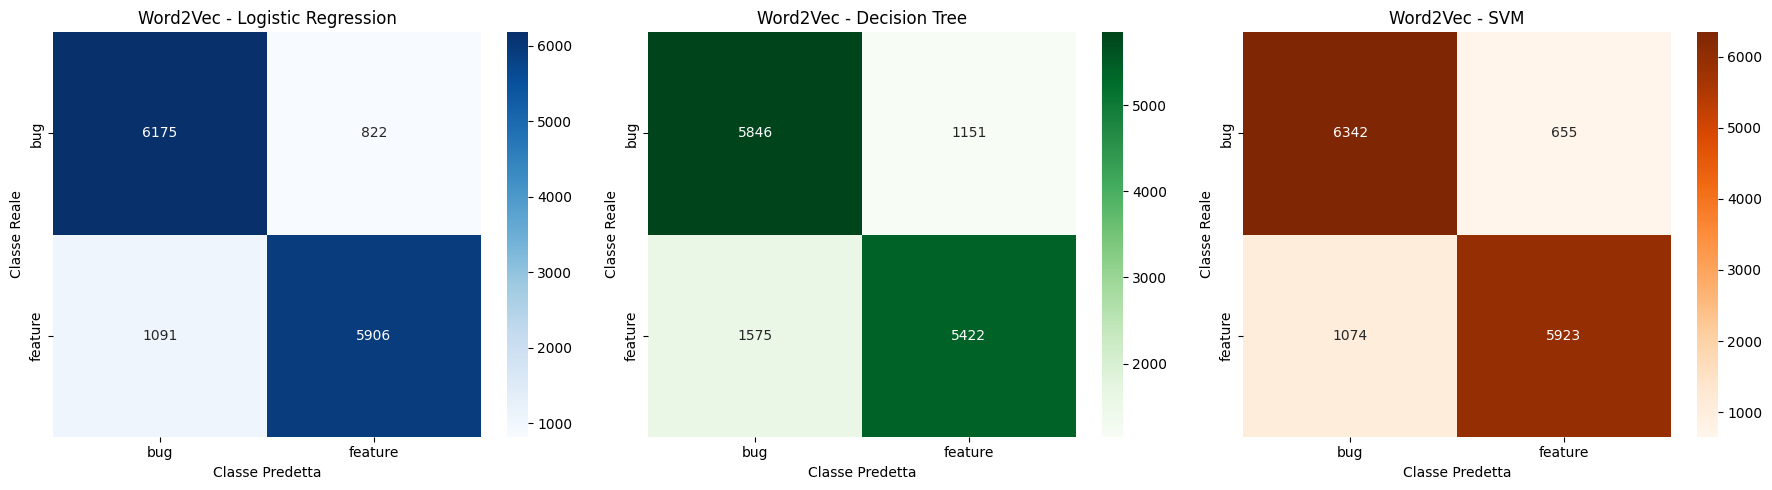

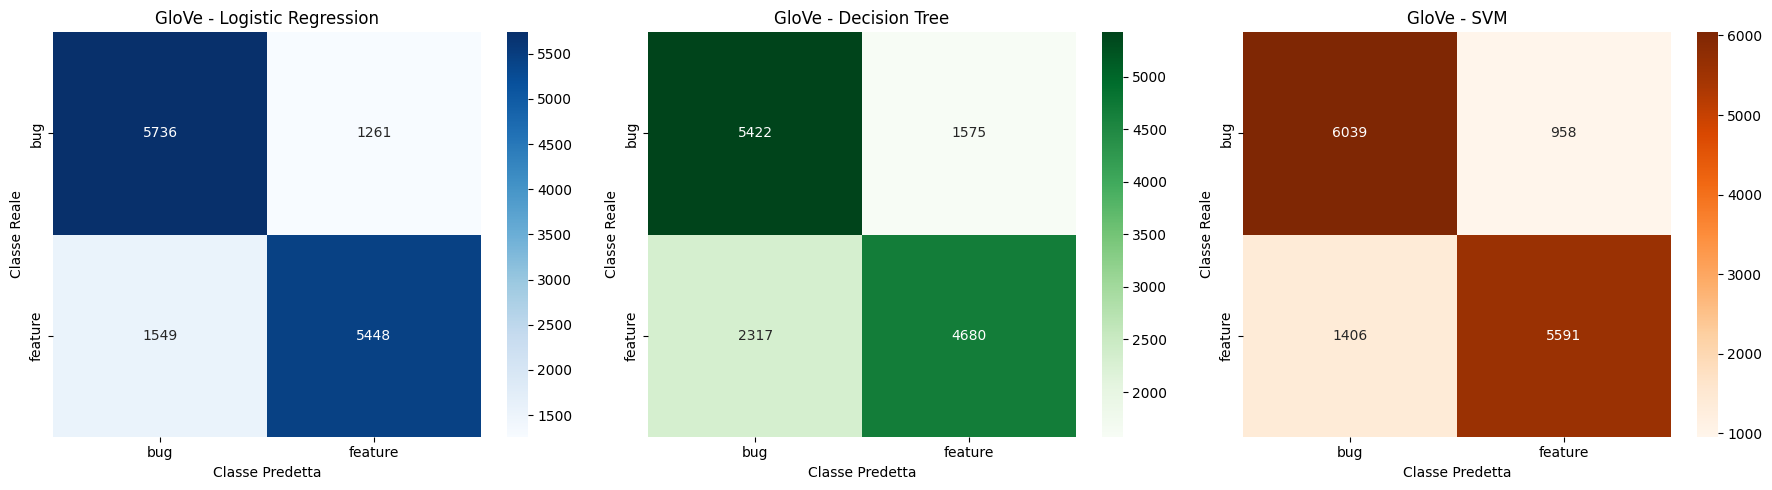

In [11]:
def display_final_comparison(final_results):
    for exp_name, models_data in final_results.items():
        print(f"\n{'='*20} {exp_name.upper()}: CONFRONTO FINALE DELLE METRICHE (TEST SET) {'='*20}")
        
        # Preparazione dei dati per la tabella
        metrics_list = ["accuracy", "precision", "recall", "f1_score"]
        table_data = []
        
        for metric in metrics_list:
            row = {"Metric": metric.capitalize().replace("_", "-")}
            for model_name, metrics in models_data.items():
                # Formattazione del nome colonna per somigliare al tuo esempio
                col_name = f"{model_name.replace('_', ' ').title()}"
                row[col_name] = metrics[metric]
            table_data.append(row)
        
        # Creazione DataFrame e stampa
        df_compare = pd.DataFrame(table_data).set_index("Metric")
        print(df_compare.to_string())
        print("-" * 80)

# Esecuzione della funzione di visualizzazione
display_final_comparison(final_results)

# Richiamo opzionale della funzione plot già definita per avere i grafici vicini ai dati
plot_confusion_matrices("Word2Vec", final_results["Word2Vec"], le.classes_)
plot_confusion_matrices("GloVe", final_results["GloVe"], le.classes_)

Salvataggio Risultati

In [12]:
# Esportazione in JSON
for exp in ["Word2Vec", "GloVe"]:
    output_path = f"../results/{exp.lower()}_results.json"
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(final_results[exp], f, indent=4, ensure_ascii=False)
    print(f"Risultati {exp} salvati in: {output_path}")

Risultati Word2Vec salvati in: ../results/word2vec_results.json
Risultati GloVe salvati in: ../results/glove_results.json
